
Sample1.csv - Sample1
  Pic : 531.94 nm ; 0.9974 a.u.


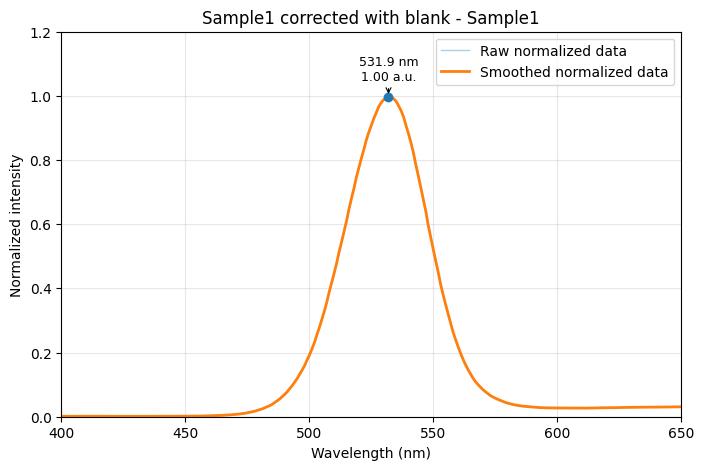


Sample2.csv - Sample2
  Pic : 586.95 nm ; 0.9973 a.u.


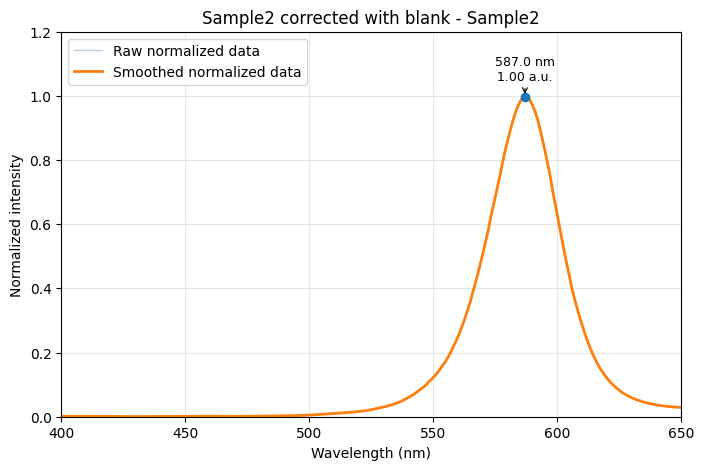


Sample3.csv - Sample3
  Pic : 595.00 nm ; 0.0411 a.u.


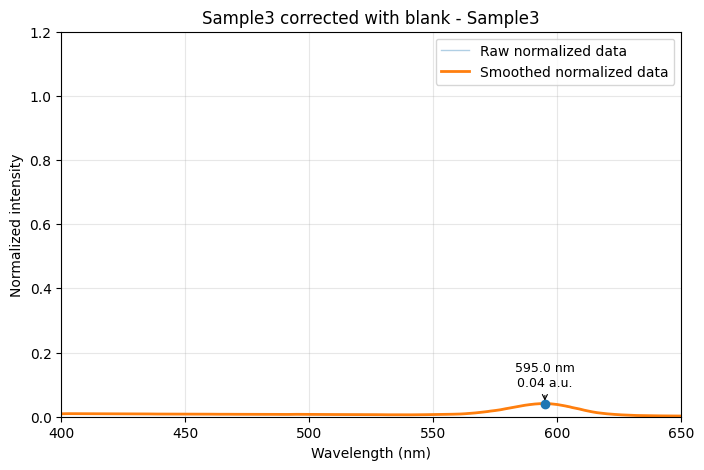


Sample4.csv - Sample4
  Pic : 585.94 nm ; 1.0018 a.u.


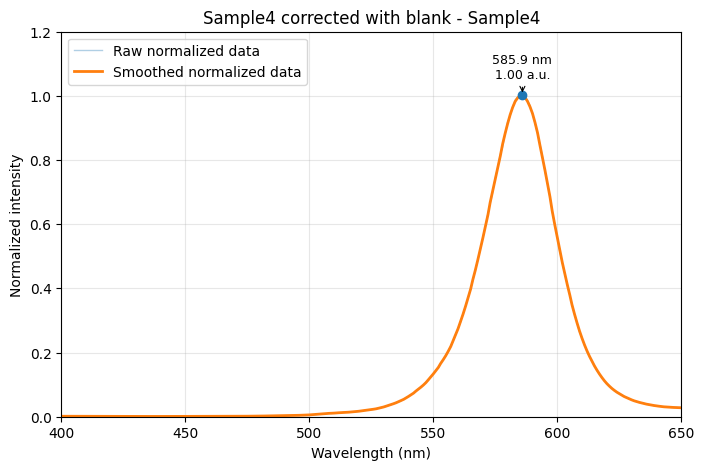


Sample5.csv - Sample5
  Pic : 557.94 nm ; 0.9983 a.u.


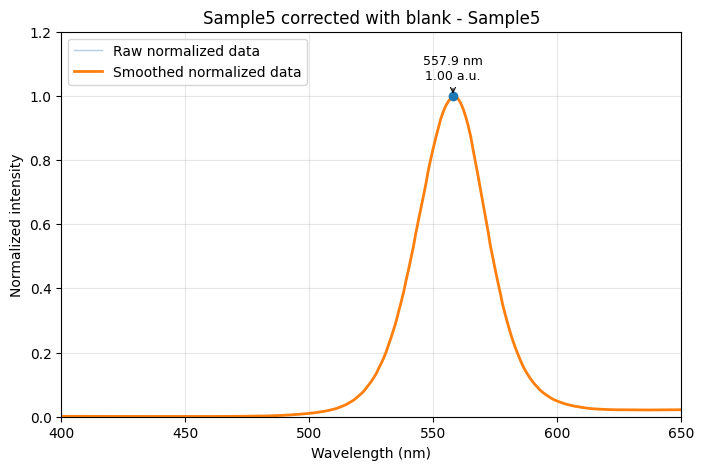

In [4]:
# plot_fluorescence_peaks.py
# Script pour tracer des spectres de fluorescence depuis des CSV
# et annoter automatiquement les pics sur les graphes.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter



# =========================
# PARAMÈTRES À MODIFIER
# =========================
DOSSIER_CSV = "C:\\Users\\jmgra\\OneDrive\\Bureau\\physical experimental code\\CdSe\\Data Fluorescence"              # dossier contenant les fichiers CSV
DOSSIER_SORTIE = "figures"     # dossier où sauver les graphes
CORRIGER_BLANK = True          # True = Sample - Blank si un Blank est présent
NOMBRE_MAX_PICS = 1            # nombre max de pics annotés par spectre
PROMINENCE = 0.05              # augmente si trop de faux pics, diminue si pics manqués
DISTANCE = 10                  # distance minimale entre pics, en nombre de points
AFFICHER = True                # True = affiche les graphes en plus de les sauver


def lire_csv_fluorescence(fichier):
    """
    Lit un CSV du type :
    ligne 1 : Blank,,Sample1,,
    ligne 2 : Wavelength (nm),Intensity (a.u.),Wavelength (nm),Intensity (a.u.),
    """
    brut = pd.read_csv(fichier, header=None)

    spectres = {}

    # Les noms des échantillons sont sur la première ligne,
    # généralement aux colonnes 0, 2, 4, ...
    for col in range(0, brut.shape[1] - 1, 2):
        nom = brut.iloc[0, col]

        if pd.isna(nom):
            continue

        x = pd.to_numeric(brut.iloc[2:, col], errors="coerce")
        y = pd.to_numeric(brut.iloc[2:, col + 1], errors="coerce")

        masque = x.notna() & y.notna()
        x = x[masque].to_numpy()
        y = y[masque].to_numpy()

        if len(x) > 0:
            spectres[str(nom)] = (x, y)

    return spectres


def annoter_pics(ax, x, y, nombre_max_pics=3, prominence=0.05, distance=10):
    """
    Détecte les pics et écrit leurs coordonnées sur le graphe.
    """
    
    prominence_min = 0.05 * (np.max(y) - np.min(y))
    height_min = np.min(y) + 0.15 * (np.max(y) - np.min(y))
    pics, proprietes = find_peaks(y, prominence=prominence_min, distance=20, height=height_min)

    if len(pics) == 0:
        return []

    # On garde les pics les plus intenses
    pics_tries = sorted(pics, key=lambda i: y[i], reverse=True)[:nombre_max_pics]
    pics_tries = sorted(pics_tries, key=lambda i: x[i])

    for i in pics_tries:
        ax.scatter(x[i], y[i], zorder=3)
        ax.annotate(
            f"{x[i]:.1f} nm\n{y[i]:.2f} a.u.",
            xy=(x[i], y[i]),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            arrowprops=dict(arrowstyle="->", lw=0.8),
        )

    return [(x[i], y[i]) for i in pics_tries]


def traiter_fichier(fichier, dossier_sortie):
    spectres = lire_csv_fluorescence(fichier)

    blank = spectres.get("Blank", None)

    for nom, (x, y) in spectres.items():
        if nom.lower() == "blank":
            continue

        y_plot = y.copy()
        titre = nom

        if CORRIGER_BLANK and blank is not None:
            x_blank, y_blank = blank

            # Interpolation au cas où les longueurs d’onde ne sont pas parfaitement identiques
            y_blank_interp = np.interp(x, x_blank, y_blank)
            y_plot = y - y_blank_interp
            titre = f"{nom} corrected with blank"

        # Normalisation entre 0 et 1
        y_norm = y_plot / np.max(y_plot)

        # Lissage du signal normalisé
        y_smooth = savgol_filter(y_norm, window_length=11, polyorder=3)

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(x, y_norm, linewidth=1, alpha=0.35, label="Raw normalized data")
        ax.plot(x, y_smooth, linewidth=2, label="Smoothed normalized data")

        pics = []

        # Cas des petits signaux
        if "sample3" in nom.lower():
            zone_pic = (x > 570) & (x < 620)

            x_zone = x[zone_pic]
            y_zone = y_smooth[zone_pic]

            indice_max = np.argmax(y_zone)

            x_pic = x_zone[indice_max]
            y_pic = y_zone[indice_max]

            pics = [(x_pic, y_pic)]

            ax.scatter(x_pic, y_pic, zorder=3)
            ax.annotate(
                f"{x_pic:.1f} nm\n{y_pic:.2f} a.u.",
                xy=(x_pic, y_pic),
                xytext=(0, 12),
                textcoords="offset points",
                ha="center",
                fontsize=9,
                arrowprops=dict(arrowstyle="->", lw=0.8),
            )

        # Cas normal
        else:
            pics = annoter_pics(
                ax,
                x,
                y_smooth,
                nombre_max_pics=NOMBRE_MAX_PICS,
                prominence=PROMINENCE,
                distance=DISTANCE,
            )

        ax.set_title(f"{titre} - {fichier.stem}")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Normalized intensity")
        ax.set_xlim(400, 650)
        ax.set_ylim(0, 1.2)
        ax.legend()
        ax.grid(True, alpha=0.3)

        nom_sortie = dossier_sortie / f"{fichier.stem}_{nom}_peaks.png"
        fig.savefig(nom_sortie, dpi=300)

        print(f"\n{fichier.name} - {nom}")
        if pics:
            for longueur_onde, intensite in pics:
                print(f"  Pic : {longueur_onde:.2f} nm ; {intensite:.4f} a.u.")
        else:
            print("  Aucun pic détecté.")

        if AFFICHER:
            plt.show()
        else:
            plt.close(fig)


def main():
    dossier_csv = Path(DOSSIER_CSV)
    dossier_sortie = Path(DOSSIER_SORTIE)
    dossier_sortie.mkdir(exist_ok=True)

    fichiers = sorted(dossier_csv.glob("*.csv"))

    if not fichiers:
        raise FileNotFoundError(f"Aucun fichier CSV trouvé dans : {dossier_csv.resolve()}")

    for fichier in fichiers:
        traiter_fichier(fichier, dossier_sortie)


if __name__ == "__main__":
    main()
